# 08. The play outcome model (M6)

**License: this notebook's outputs are CC BY-SA 4.0.** They are derived from nflverse participation data: NFL Next Gen Stats via nflverse (2016-2022) and FTN Data via nflverse (2023+). Nothing here feeds A4s or any CC BY artifact.

Walker's question: *given the situation and the players on the field, how many yards will this play gain?* M6 answers with a **whole distribution** over yards, not one number. The method is `context/ml-m6-method.md`; the results are in `context/ml.md` ("M6 build notes").

1. Distributions versus point estimates
2. CRPS from first principles
3. What the pre-snap structure says: box count, personnel, formation
4. Embeddings and DeepSets, with a tiny example
5. Dev results (from the registry)
6. One situation, four distributions: 3rd-and-2 vs 3rd-and-9, run vs pass
7. Calibration and the player embeddings

Everything here uses the development seasons only (2016-2019). The holdout (2020-2025) is not touched.

In [1]:
import json
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "nflelo").is_dir())
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ml_m6
from nflelo.ml import data as D, registry
from nflelo.ml.plays import data as pdata, metrics as pm, net

plt.rcParams.update({"figure.figsize": (9, 3.6), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
pd.set_option("display.width", 160)
INK, ACCENT, MUTED, BAD, MODEL = "#1f2a44", "#2f6fdf", "#9aa3b2", "#d1495b", "#2a9d8f"
OUT = D.ML_DIR / "m6"
DEV = json.loads((OUT / "dev.json").read_text())

# the play table for 2016-2019 (dev data only); player priors are not needed here
world = ml_m6.load_world(2019, priors={})
T = world.table
train = T[T["season"] <= 2017]          # descriptive plots use training seasons only
print(f"{len(T):,} kept plays 2016-2019; {len(train):,} in 2016-2017")

111,961 kept plays 2016-2019; 56,418 in 2016-2017


## 1. Distributions versus point estimates

A play's yards are not a bell curve. Incomplete passes put a spike at exactly 0. Most runs gain 0 to 6. Sacks pull passes negative. A few plays break for 40 or more. The **mean** hides all of that: two plays can both average 5 yards while one is a safe 4-6 and the other is "incomplete or a big gain".

So M6 predicts probabilities over **53 yard bins**: -10 or worse, each yard from -9 to +40, 41+ (short of the end zone), and touchdown. The field truncates the distribution: from the opponent's 8 a play can't gain 30, so everything at 8 yards or more is folded into the touchdown bin.

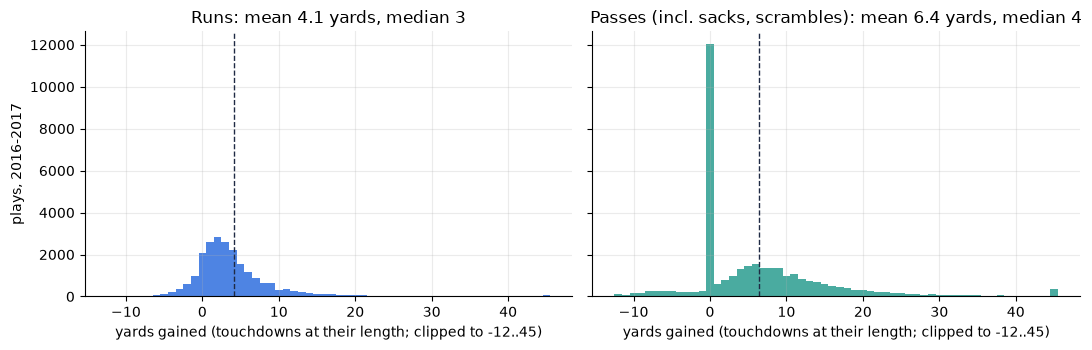

Share of passes at exactly 0 yards: 34.8%; runs gaining 20+: 2.4%; passes gaining 20+: 8.3%


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, (name, sub) in zip(axes, [("Runs", train[train["is_pass"] == 0]), ("Passes (incl. sacks, scrambles)", train[train["is_pass"] == 1])]):
    y = sub["yards"].clip(-12, 45)
    ax.hist(y, bins=np.arange(-12.5, 46.5, 1), color=ACCENT if "Run" in name else MODEL, alpha=0.85)
    ax.axvline(sub["yards"].mean(), color=INK, ls="--", lw=1)
    ax.set_title(f"{name}: mean {sub['yards'].mean():.1f} yards, median {sub['yards'].median():.0f}")
    ax.set_xlabel("yards gained (touchdowns at their length; clipped to -12..45)")
axes[0].set_ylabel("plays, 2016-2017")
plt.tight_layout(); plt.show()
print(f"Share of passes at exactly 0 yards: {(train.loc[train.is_pass == 1, 'yards'] == 0).mean():.1%}; "
      f"runs gaining 20+: {(train.loc[train.is_pass == 0, 'yards'] >= 20).mean():.1%}; "
      f"passes gaining 20+: {(train.loc[train.is_pass == 1, 'yards'] >= 20).mean():.1%}")

The dashed line is the mean. For passes it sits in a valley between the incompletion spike and the completions, a value few passes actually produce. From the distribution we can read off what decisions need: expected yards, P(first down or TD), P(20+ yards), and P(loss).

## 2. CRPS from first principles

How do we score a distribution? The **continuous ranked probability score** (here its discrete form, the ranked probability score) compares the forecast's cumulative distribution with the outcome's step function, threshold by threshold:

$$\text{CRPS} = \sum_k \big(F(k) - \mathbb{1}[y \le k]\big)^2$$

with $F(k)$ the forecast probability of gaining $k$ yards or fewer. Between -9 and +40 the thresholds are one yard apart, so CRPS is measured **in yards**. Three facts make it the right primary metric:

- For a point forecast (all mass on one value) it equals the absolute error: forecast 0 and gain 3, CRPS is 3.
- It rewards being close, not just being right: unlike log loss, putting mass on 4 yards when 5 happens earns most of the credit.
- It is proper: the best expected score comes from forecasting the true distribution.

The NFL's own Big Data Bowl scored its rushing-yards contest with it.

In [3]:
def crps_by_hand(p, outcome, yards):
    F = np.cumsum(p)
    H = (yards >= outcome).astype(float)
    return float(((F - H) ** 2)[:-1].sum())

yards = np.arange(-2, 11)                      # a toy field: -2 .. +10 yards
point = (yards == 0).astype(float)             # "it will gain 0"
spread = np.exp(-0.5 * ((yards - 3) / 3) ** 2); spread /= spread.sum()   # "about 3, give or take"
for name, p in [("point at 0", point), ("spread around 3", spread)]:
    print(f"{name:<16}" + "  ".join(f"y={y}: {crps_by_hand(p, y, yards):.2f}" for y in (0, 3, 8)))

# the module's CRPS on the 53 bins gives the same numbers
p = np.zeros((1, 53)); p[0, 10] = 1.0          # all mass on 0 yards
print("pm.crps, point at 0, outcome +3 yards:", pm.crps(p, np.array([13]), np.array([50]))[0])

point at 0      y=0: 0.00  y=3: 3.00  y=8: 8.00
spread around 3 y=0: 1.90  y=3: 0.65  y=8: 3.37
pm.crps, point at 0, outcome +3 yards: 3.0


The point forecast is perfect when it is exactly right and pays the full distance otherwise. The spread forecast never scores 0, but it is cheaper on average when outcomes vary, which is the situation on a football field. One more detail: near the goal line the impossible yards between "last yard of the field" and "touchdown" are skipped, so a touchdown from the 3 is three yards beyond a 0-yard forecast, not 43.

## 3. What the pre-snap structure says

The models only see what both teams can see **at the snap**: the situation, the personnel groupings, the formation, the number of defenders in the box, and the two teams' ratings as of the start of the week. Not the number of pass rushers, the coverage, routes, pressure, or air yards: those exist in the data but only after the snap, so a banned-columns test keeps them out.

The participation source changed in 2023 (NGS to FTN): formation names and personnel strings use different vocabularies, so both are mapped to one encoding (shotgun / pistol / under center; RB / TE / WR / OL and DL / LB / DB counts). The table below is the field report from `ml_m6.py fields`: every season 2016-2025, pre-snap fields only (no outcome of a holdout season is read). Personnel stays steady across the switch; the box count's spread narrows in 2024-2025 (8+ boxes halve), which is why the holdout reports the NGS and FTN seasons separately.

In [4]:
fields = pd.DataFrame(json.loads((OUT / "fields.json").read_text())["fields"])
fields[["season", "era", "plays", "raw_formations", "form_missing", "shotgun", "pistol", "under_center",
        "box_mean", "box_sd", "rb", "te", "wr", "p11", "dl", "lb", "db"]].round(3)

,season,era,plays,raw_formations,form_missing,shotgun,pistol,under_center,box_mean,box_sd,rb,te,wr,p11,dl,lb,db
0,2016,ngs,28367,7,0.009,0.592,0.040,0.355,6.371,1.059,1.100,1.237,2.606,0.587,3.201,3.009,4.786
1,2017,ngs,28051,7,0.008,0.570,0.016,0.403,6.492,1.081,1.122,1.305,2.527,0.578,3.245,2.980,4.772
2,2018,ngs,27611,7,0.009,0.607,0.020,0.362,6.374,1.050,1.108,1.260,2.584,0.621,3.412,2.706,4.880
3,2019,ngs,27932,7,0.001,0.604,0.032,0.360,6.341,1.048,1.120,1.278,2.547,0.571,3.149,2.991,4.854
4,2020,ngs,28715,7,0.004,0.623,0.032,0.338,6.347,1.036,1.106,1.290,2.567,0.576,3.407,2.713,4.878
5,2021,ngs,29535,7,0.007,0.620,0.030,0.339,6.363,1.032,1.101,1.299,2.555,0.583,3.216,2.912,4.869
6,2022,ngs,30412,7,0.001,0.629,0.045,0.318,6.370,1.014,1.116,1.305,2.547,0.611,3.166,2.999,4.833
7,2023,ftn,30040,3,0.003,0.681,0.041,0.275,6.271,1.087,1.089,1.279,2.594,0.621,3.168,2.938,4.892
8,2024,ftn,29489,3,0.001,0.614,0.096,0.289,6.103,0.930,1.080,1.327,2.561,0.612,3.230,2.917,4.848
9,2025,ftn,29354,3,0.002,0.608,0.049,0.341,6.231,0.841,1.097,1.363,2.476,0.564,3.075,3.147,4.772


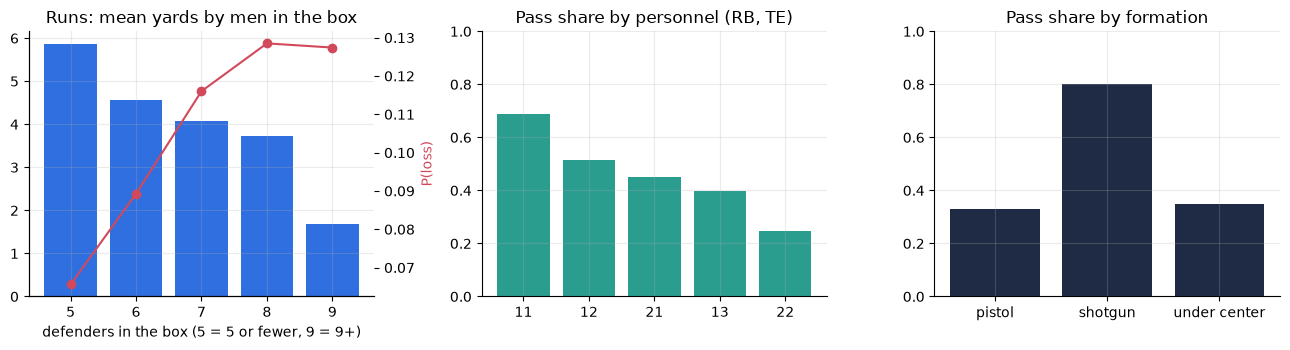

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
runs = train[train["is_pass"] == 0]
g = runs.groupby(runs["box"].clip(5, 9))
ax = axes[0]
ax.bar(g.size().index, g["yards"].mean(), color=ACCENT)
ax.set_title("Runs: mean yards by men in the box"); ax.set_xlabel("defenders in the box (5 = 5 or fewer, 9 = 9+)")
ax2 = ax.twinx(); ax2.plot(g.size().index, g["ev_loss"].mean(), color=BAD, marker="o"); ax2.set_ylabel("P(loss)", color=BAD)
ax2.grid(False)
pers = train.assign(pers=train["off_rb"].astype(int).astype(str) + train["off_te"].astype(int).astype(str))
top = pers["pers"].value_counts().index[:5]
s = pers[pers["pers"].isin(top)].groupby("pers")["is_pass"].mean().reindex(top)
axes[1].bar(s.index, s.values, color=MODEL); axes[1].set_title("Pass share by personnel (RB, TE)"); axes[1].set_ylim(0, 1)
form = np.select([train.form_shotgun == 1, train.form_pistol == 1], ["shotgun", "pistol"], "under center")
f = train.assign(form=form).groupby("form")["is_pass"].mean()
axes[2].bar(f.index, f.values, color=INK); axes[2].set_title("Pass share by formation"); axes[2].set_ylim(0, 1)
plt.tight_layout(); plt.show()

Each extra defender in the box takes yards away from runs and adds losses. Personnel and formation are strong tells of the call: "11" (1 RB, 1 TE) in the shotgun is mostly a pass, two tight ends under center mostly a run. That's why the **situation view** (no play type given) gains more from these fields than the **call-conditioned view**, where the play type is already an input.

A data warning found while building this: in the NGS seasons the formation field is **missing on about 1% of plays, and 83-89% of those are fumbles** (strip sacks, 2016-2018). A model allowed to see "formation missing" learned to predict turnovers from it (turnover Brier 0.0144 against a 0.0198 base rate in a first test). Missing formations are now filled from play-by-play's own shotgun flag, and no missing-value flag is a feature except for indoor weather.

## 4. Embeddings and DeepSets, with a tiny example

The networks N1 and N2 also see **who** is on the field. Each player gets an **embedding**: a short vector of numbers the network learns, like a learned scouting report. A player who keeps showing up on plays that go well for his side ends up with a vector that pushes predictions that way.

The 22 players come as two **sets**. Their order in the data means nothing (it's sorted by ID), so the network must not care about it. **DeepSets** does this: apply the same small network φ to each player's embedding, then average. An average doesn't depend on order, so the result is the same however the 11 are listed.

In [6]:
import torch
torch.manual_seed(0)
emb = torch.nn.Embedding(5, 3)                         # 5 players, 3 numbers each
phi = torch.nn.Sequential(torch.nn.Linear(3, 4), torch.nn.ReLU(), torch.nn.Linear(4, 4))
lineup = torch.tensor([[1, 2, 3]])                     # three players on the field
shuffled = torch.tensor([[3, 1, 2]])                   # the same three, listed differently
pool = lambda ids: phi(emb(ids)).mean(dim=1)
print("pooled, original order:", pool(lineup).detach().numpy().round(4))
print("pooled, shuffled order:", pool(shuffled).detach().numpy().round(4))
print("swap one player:      ", pool(torch.tensor([[1, 2, 4]])).detach().numpy().round(4))

pooled, original order: [[ 0.6571 -0.1155 -0.2662  0.1446]]
pooled, shuffled order: [[ 0.6571 -0.1155 -0.2662  0.1446]]
swap one player:       [[ 0.8509 -0.1774 -0.3584  0.1512]]


Same three players, same pooled vector; swap one player and it changes. In M6 the offensive and defensive sets have separate embeddings and separate φ networks, and the two pooled vectors join the situation features in the main network ("trunk"). Players never seen in training get a zero vector. N2 also feeds φ each player's M5 box-score value and M5b RAPM value as of the start of the season, so the learned embedding only has to explain what those miss, and the embedding penalty pulls it toward zero (that is, toward the prior values).

The point of the ablation is simple: **once personnel, formation, box count and team ratings are known, does knowing the individual players help?** M5b suggested very little.

## 5. Dev results (from the registry)

Season-ahead: predict 2018 from 2016-2017 and 2019 from 2016-2018, every kept play (REG and POST). Tuning only uses the training seasons (fit on all but the last, compare on the last). CIs resample whole games (2,000 replicates).

In [7]:
runs = [r for r in registry.load_runs() if r.get("label") == "m6dev" and r["name"].startswith("m6_")]
latest = {}
for r in sorted(runs, key=lambda r: r["timestamp"]):
    latest[r["name"]] = r
rows = []
for name, r in latest.items():
    x = r["result"]
    vb = (x.get("vs_baseline") or {}).get("crps")
    rows.append({"view": r["view"], "model": r["model"], "CRPS": x["crps"], "log loss": x["logloss"],
                 "turnover Brier": x["tov_brier"],
                 "CRPS vs baseline": None if vb is None else f"{vb['diff']:+.4f} [{vb['ci_low']:+.4f}, {vb['ci_high']:+.4f}]",
                 "ECE P(first)": x["cal_first"]["ece"], "null p95": x["cal_first"]["null_p95"],
                 "one-SE pick": "yes" if r["one_se"]["chosen_this"] else ""})
res = pd.DataFrame(rows)
order = {m: i for i, m in enumerate(ml_m6.MODELS)}
res = res.sort_values(["view", "model"], key=lambda s: s.map(order) if s.name == "model" else s)
print(f"{len(runs)} m6 dev runs in the registry; plays per view: {next(iter(latest.values()))['n']:,}")
res.round(4)

10 m6 dev runs in the registry; plays per view: 55,543


,view,model,CRPS,log loss,turnover Brier,CRPS vs baseline,ECE P(first),null p95,one-SE pick
0,call,baseline,3.9484,2.8710,0.0198,NaN,0.0046,0.0057,
9,call,gbm,3.9304,2.8528,0.0198,"-0.0180 [-0.0208, -0.0152]",0.0058,0.0056,yes
6,call,N0,3.9324,2.8513,0.0198,"-0.0160 [-0.0195, -0.0125]",0.0060,0.0056,
7,call,N1,3.9310,2.8492,0.0198,"-0.0174 [-0.0213, -0.0139]",0.0053,0.0056,
8,call,N2,3.9301,2.8493,0.0198,"-0.0183 [-0.0224, -0.0145]",0.0042,0.0056,
4,situation,baseline,4.0245,2.9731,0.0199,NaN,0.0061,0.0056,
5,situation,gbm,4.0059,2.9442,0.0198,"-0.0185 [-0.0217, -0.0155]",0.0052,0.0057,yes
1,situation,N0,4.0092,2.9454,0.0199,"-0.0152 [-0.0188, -0.0117]",0.0053,0.0058,
2,situation,N1,4.0096,2.9445,0.0199,"-0.0148 [-0.0187, -0.0110]",0.0052,0.0059,
3,situation,N2,4.0098,2.9445,0.0199,"-0.0146 [-0.0185, -0.0106]",0.0051,0.0056,


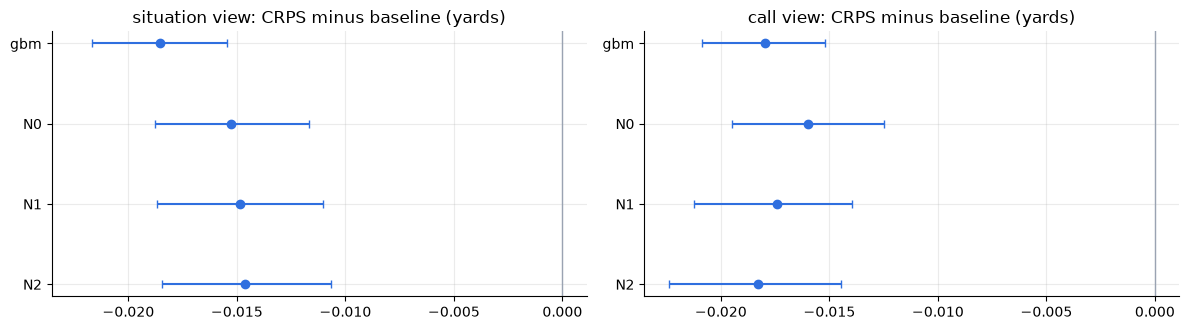

situation: one-SE {'best': 'gbm', 'within': ['gbm'], 'chosen': 'gbm'}; ablation N1-N0 +0.0004 [-0.0009, +0.0018], N2-N0 +0.0006 [-0.0008, +0.0021], gbm-N0 -0.0033 [-0.0055, -0.0011]
call: one-SE {'best': 'N2', 'within': ['gbm', 'N2'], 'chosen': 'gbm'}; ablation N1-N0 -0.0014 [-0.0030, +0.0002], N2-N0 -0.0023 [-0.0040, -0.0004], gbm-N0 -0.0020 [-0.0046, +0.0007]


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), sharex=True)
for ax, view in zip(axes, ["situation", "call"]):
    v = DEV["views"][view]
    ms = [m for m in ml_m6.MODELS if m != "baseline"]
    d = [v["models"][m]["vs_baseline"]["crps"] for m in ms]
    y = np.arange(len(ms))
    ax.errorbar([x["diff"] for x in d], y, xerr=[[x["diff"] - x["ci_low"] for x in d], [x["ci_high"] - x["diff"] for x in d]],
                fmt="o", color=ACCENT, capsize=3)
    ax.axvline(0, color=MUTED, lw=1); ax.set_yticks(y, ms); ax.invert_yaxis()
    ax.set_title(f"{view} view: CRPS minus baseline (yards)")
plt.tight_layout(); plt.show()
for view in ["situation", "call"]:
    v = DEV["views"][view]
    print(f"{view}: one-SE {v['one_se']}; ablation N1-N0 {ml_m6.fmt_ci(v['pairs']['N1-N0'])}, "
          f"N2-N0 {ml_m6.fmt_ci(v['pairs']['N2-N0'])}, gbm-N0 {ml_m6.fmt_ci(v['pairs']['gbm-N0'])}")

How to read it: each dot is a model's average CRPS minus the baseline's, on the same plays, with a 95% game-cluster interval. Left of zero is better. The improvements are a few hundredths of a yard on a CRPS of about 4 yards: most of a play's outcome is not predictable before the snap, so even a good model only trims the edges. The one-SE rule then picks the simplest model whose CRPS is within one bootstrap standard error of the best.

In [9]:
rows = []
for view in ["situation", "call"]:
    for name, s in DEV["views"][view]["splits"].items():
        if name.startswith("era"):
            continue
        rows.append({"view": view, "split": name, "plays": s["n"], "baseline CRPS": s["baseline"]["crps"],
                     **{m: f"{s[m]['vs_baseline']['diff']:+.4f}" + ("*" if s[m]['vs_baseline']['ci_high'] < 0 else "")
                        for m in ml_m6.MODELS if m != "baseline"}})
print("Model minus baseline CRPS by split (* = 95% CI entirely below 0)")
pd.DataFrame(rows).round(3)

Model minus baseline CRPS by split (* = 95% CI entirely below 0)


,view,split,plays,baseline CRPS,gbm,N0,N1,N2
0,situation,run,21113,2.796,-0.0083*,-0.0178*,-0.0198*,-0.0160*
1,situation,pass,34430,4.778,-0.0248*,-0.0137*,-0.0118*,-0.0137*
2,situation,down1,25063,3.936,-0.0180*,-0.0133*,-0.0113*,-0.0133*
3,situation,down2,18547,3.900,-0.0221*,-0.0184*,-0.0186*,-0.0170*
4,situation,down3,11190,4.459,-0.0145*,-0.0156*,-0.0169*,-0.0136*
5,situation,down4,743,3.581,-0.0092,+0.0036,-0.0088,-0.0143
6,situation,zone_1_20,7951,2.344,-0.0242*,-0.0186*,-0.0181*,-0.0200*
7,situation,zone_21_50,16376,4.201,-0.0157*,-0.0089*,-0.0108*,-0.0100*
8,situation,zone_51_80,26211,4.394,-0.0178*,-0.0159*,-0.0144*,-0.0138*
9,situation,zone_81_99,5005,4.185,-0.0227*,-0.0270*,-0.0253*,-0.0252*


## 6. One situation, four distributions

An illustration (not a result): the call-view network N0 trained on 2016-2018 (the one that predicted 2019), on made-up plays from the offense's own 45 (55 yards to go): 3rd-and-2 versus 3rd-and-9, a run versus a pass. Everything else is set to a typical play (11 personnel in the shotgun, six in the box, average teams, second quarter, tied).

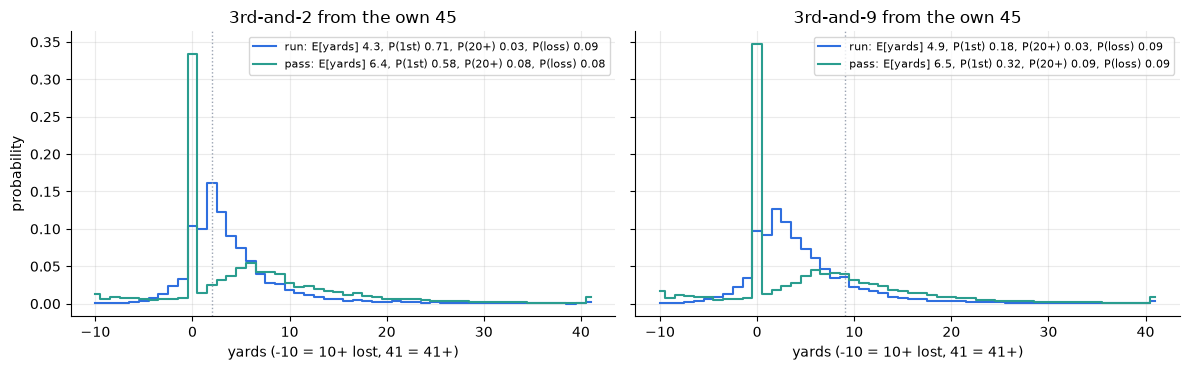

In [10]:
model = net.PlayModel.load(OUT / "net_call_N0_2019.pt")
base = T[T["season"] == 2019].iloc[[0]].copy()
typical = {"down": 3, "yardline_100": 55, "score_diff": 0, "half_secs": 600, "game_secs": 2400, "off_timeouts": 3,
           "def_timeouts": 3, "home": 1, "roof_indoor": 0, "roof_open": 0, "temp": 60, "wind": 5, "off_rb": 1,
           "off_te": 1, "off_wr": 3, "off_ol": 5, "def_dl": 4, "def_lb": 2, "def_db": 5, "form_shotgun": 1,
           "form_pistol": 0, "form_under_center": 0, "box": 6, "off_pass_o": 0, "off_rush_o": 0, "def_pass_d": 0,
           "def_rush_d": 0}
cases = []
for ytg in (2, 9):
    for is_pass in (0, 1):
        row = base.copy()
        for k, v in {**typical, "ydstogo": ytg, "is_pass": is_pass}.items():
            row[k] = v
        cases.append(row)
X = pd.concat(cases, ignore_index=True)
P, tov = model.predict(X)
ev = pm.event_probs(P, X["ydstogo"].to_numpy(float), X["yardline_100"].to_numpy(float))
ey = pm.expected_yards(P, X["yardline_100"].to_numpy(float))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
x = np.arange(-10, 42)
for ax, ytg in zip(axes, (2, 9)):
    for i in range(len(X)):
        if X.loc[i, "ydstogo"] != ytg:
            continue
        lab = "pass" if X.loc[i, "is_pass"] == 1 else "run"
        ax.step(x, P[i, :52], where="mid", color=MODEL if lab == "pass" else ACCENT,
                label=f"{lab}: E[yards] {ey[i]:.1f}, P(1st) {ev['first'][i]:.2f}, P(20+) {ev['20plus'][i]:.2f}, P(loss) {ev['loss'][i]:.2f}")
    ax.axvline(ytg, color=MUTED, ls=":", lw=1)
    ax.set_title(f"3rd-and-{ytg} from the own 45"); ax.set_xlabel("yards (-10 = 10+ lost, 41 = 41+)")
    ax.legend(fontsize=8, loc="upper right")
axes[0].set_ylabel("probability")
plt.tight_layout(); plt.show()

The run is a tight hump around 2-5 yards with about a 9% chance of a loss; the pass has the incompletion spike at 0 (about a third of the mass), a long right tail (P(20+) about 0.08-0.09 against 0.03 for the run), and its own loss risk from sacks. On 3rd-and-2 the run converts more often (about 0.71 against 0.58) because its mass sits just past the marker; on 3rd-and-9 it flips (about 0.18 for the run against 0.32 for the pass). Expected yards favor the pass in both cases (about 6.4-6.5 against 4.3-4.9), which is exactly why the mean alone is a poor guide: the decision depends on the distance to gain. This is the kind of comparison M7 (decision support) builds on, with the caveat that M7 must deal with selection: teams choose when to run, so "the pass on 3rd-and-2" in the data is not a random pass.

## 7. Calibration and the player embeddings

When the chosen model says P(first down or TD) = 0.40, does the offense convert about 40% of the time? The reliability curve below pools the dev predictions (2018-2019).

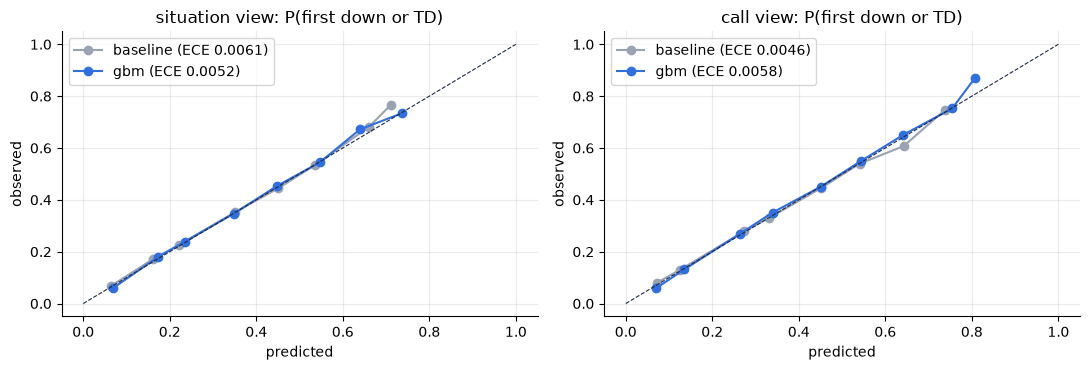

In [11]:
pred = pd.read_parquet(OUT / "dev_predictions.parquet")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, view in zip(axes, ["situation", "call"]):
    ch = DEV["views"][view]["one_se"]["chosen"]
    f = pred[pred["view"] == view]
    for m, col in [("baseline", MUTED), (ch, ACCENT)]:
        t = pm.calibration.reliability_table(f["ev_first"], f[f"pfirst_{m}"], bins=10)
        ax.plot(t["mean_pred"], t["observed"], marker="o", color=col, label=f"{m} (ECE {DEV['views'][view]['models'][m]['cal_first']['ece']:.4f})")
    ax.plot([0, 1], [0, 1], color=INK, lw=0.8, ls="--")
    ax.set_title(f"{view} view: P(first down or TD)"); ax.set_xlabel("predicted"); ax.set_ylabel("observed"); ax.legend()
plt.tight_layout(); plt.show()

In [12]:
rows = []
for key, e in DEV.get("embedding_norms", {}).items():
    for r in e["by_snaps"]:
        rows.append({"fit": key, "training snaps": r["bin"], "players": r["count"], "mean embedding norm": r["mean"]})
print("N1 embedding size by how often the player was on the field in training (Spearman):",
      {k: round(v["spearman_norm_snaps"], 2) for k, v in DEV.get("embedding_norms", {}).items()})
pd.DataFrame(rows).round(4)

N1 embedding size by how often the player was on the field in training (Spearman): {'situation_2018': -0.63, 'situation_2019': -0.77, 'call_2018': -0.52, 'call_2019': -0.71}


,fit,training snaps,players,mean embedding norm
0,situation_2018,<100,945,0.1597
1,situation_2018,100-299,432,0.0968
2,situation_2018,300-999,758,0.0709
3,situation_2018,1000-2999,484,0.0460
4,situation_2018,3000+,0,NaN
5,situation_2019,<100,1130,0.0159
6,situation_2019,100-299,484,0.0053
7,situation_2019,300-999,753,0.0038
8,situation_2019,1000-2999,744,0.0030
9,situation_2019,3000+,1,0.0029


The pattern is the opposite of what an ideal prior would give: **players with few snaps have the largest embeddings**, regulars the smallest. The penalty is charged per appearance, so a player seen on 50 plays is barely penalized and can fit noise in those plays, while a regular's vector is pulled hard toward zero and can only move as far as thousands of plays support. (Norms are not comparable across fits: the φ network can rescale them.) A per-player penalty, stronger for rarely seen players, is the obvious next try if identities are revisited. Either way the N1-versus-N0 comparison in section 5 is the measure that matters: at most about 0.002 yards of CRPS, and only in the call view.

**Where this leaves M6.** The chosen model, the ablation and the pre-registered holdout rules are in `context/ml.md` ("M6 build notes" and "M6 holdout pre-registration"). The holdout has not been run.